# Notebook 04 — Recommendation Engine (Sentence Transformers)

## Overview
This notebook demonstrates **Technique 3: Transformer-based Models** for content-based movie recommendation using **Sentence Transformers** (`all-MiniLM-L6-v2`).

## Why Sentence Transformers over Word2Vec?
Word2Vec (Notebook 03) embeds individual words. When we need to encode a full sentence like *"a funny animated movie for the whole family"*, we had to average word vectors — losing word order and context.

**Sentence Transformers** (Reimers & Gurevych, 2019) encode entire sentences into a single vector using a fine-tuned BERT-style model. This preserves:
- Word order and grammar
- Contextual relationships ("bank" as a financial institution vs. a riverbank)
- The full semantic meaning of a sentence

## Model Used: `all-MiniLM-L6-v2`
- A lightweight 6-layer MiniLM architecture fine-tuned on 1 billion sentence pairs
- Produces 384-dimensional sentence embeddings
- Very fast inference — suitable for real-time recommendations
- Available from Hugging Face: `sentence-transformers/all-MiniLM-L6-v2`

## How Recommendation Works
1. Encode all 4,803 movie descriptions into 384-dim vectors (done once, cached)
2. Encode the user's mood/query into a vector
3. Compute **cosine similarity** between the query vector and all movie vectors
4. Return the Top-K highest scoring movies

In [6]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from src.recommender import load_data, recommend

plt.style.use('dark_background')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data and Pre-computed Embeddings

The first call computes and caches the sentence embeddings for all movies. Subsequent calls load instantly from `models/st_movie_embeddings.npy`.

In [7]:
df, movie_embeddings = load_data()
print(f'Movies: {len(df)}')
print(f'Embedding matrix shape: {movie_embeddings.shape} → ({len(df)} movies × 384 dimensions)')

Loading cached sentence-transformer embeddings...
Movies: 4803
Embedding matrix shape: (4803, 384) → (4803 movies × 384 dimensions)


## 2. Run Recommendations on Sample Queries

We test the system with diverse user inputs representing different moods and genres.

In [11]:
test_queries = [
    'a funny animated movie for the whole family',
    'dark psychological thriller with a twist ending',
    'romantic comedy set in New York',
    'epic space adventure with stunning visuals',
    'inspiring true story about overcoming adversity',
    'action-packed superhero movie with great special effects',
]

for query in test_queries:
    results, scores = recommend(query, top_k=3, df=df, movie_embeddings=movie_embeddings)
    print(f'Query: "{query}"')
    for i, (_, row) in enumerate(results.iterrows()):
        print(f'  {i+1}. {str(row["title"]):45s} | {str(row["genres"]):25s} | score: {scores[i]:.4f}')
    print()

Query: "a funny animated movie for the whole family"
  1. Doug's 1st Movie                              | Animation Family Comedy   | score: 0.6342
  2. Jimmy Neutron: Boy Genius                     | Action Adventure Animation Comedy Family Fantasy Science Fiction | score: 0.6270
  3. Jonah: A VeggieTales Movie                    | Action Adventure Animation Comedy Family Fantasy Romance | score: 0.6266

Query: "dark psychological thriller with a twist ending"
  1. They                                          | Horror Thriller           | score: 0.6791
  2. May                                           | Drama Horror Thriller Romance | score: 0.6521
  3. One Hour Photo                                | Horror Thriller           | score: 0.6484

Query: "romantic comedy set in New York"
  1. About Last Night                              | Comedy Romance            | score: 0.6946
  2. Shortbus                                      | Romance Drama Comedy      | score: 0.6513
  3. The Apar

## 3. Similarity Score Distribution

For a given query, we plot how similarity scores are distributed across all 4,803 movies. Most movies will have low similarity — the recommended movies are the long tail on the right.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

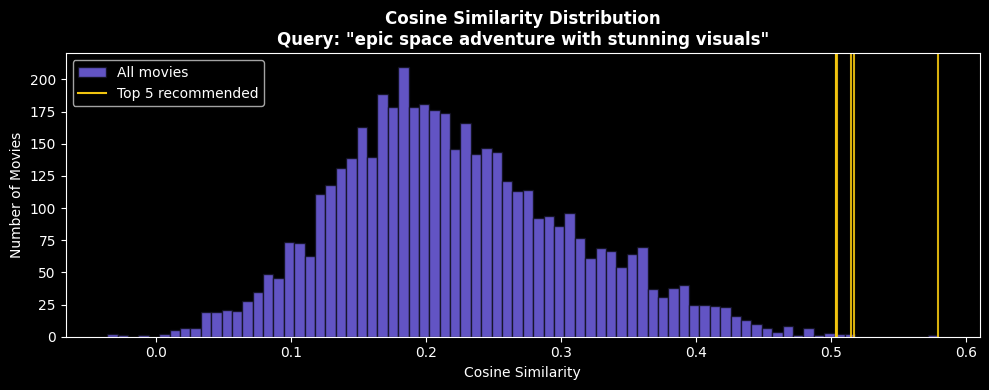

Top 5 movies: ['Final Fantasy: The Spirits Within', 'Titan A.E.', 'Star Wars: Clone Wars: Volume 1', 'The Book of Life', 'Space Pirate Captain Harlock']
Their scores: [np.float32(0.5798), np.float32(0.5174), np.float32(0.5153), np.float32(0.5044), np.float32(0.5041)]


In [12]:
model = SentenceTransformer('all-MiniLM-L6-v2')
query = 'epic space adventure with stunning visuals'
q_vec = model.encode([query])
all_scores = cosine_similarity(q_vec, movie_embeddings)[0]

top5_idx = all_scores.argsort()[::-1][:5]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_scores, bins=80, color='#7c6af7', edgecolor='#0f0f1a', alpha=0.8, label='All movies')
for idx in top5_idx:
    ax.axvline(all_scores[idx], color='#f1c40f', linewidth=1.5, alpha=0.9)
ax.axvline(all_scores[idx], color='#f1c40f', linewidth=1.5, label='Top 5 recommended')
ax.set_title(f'Cosine Similarity Distribution\nQuery: "{query}"', fontweight='bold')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/similarity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Top 5 movies: {[df.iloc[i]["title"] for i in top5_idx]}')
print(f'Their scores: {[round(all_scores[i], 4) for i in top5_idx]}')

## 4. Word2Vec vs Sentence Transformer — Qualitative Comparison

We compare recommendations from both embedding methods for the same query. This justifies the use of Sentence Transformers in our final system.

In [13]:
from src.embeddings import run_embeddings_pipeline, get_movie_vector
from gensim.models import Word2Vec
import os

query = 'animated children comedy adventure'

# Sentence Transformer results
st_results, st_scores = recommend(query, top_k=5, df=df, movie_embeddings=movie_embeddings)

# Word2Vec results
w2v_path = '../models/word2vec.model'
w2v_emb_path = '../models/w2v_movie_embeddings.npy'
if os.path.exists(w2v_path) and os.path.exists(w2v_emb_path):
    w2v_model = Word2Vec.load(w2v_path)
    w2v_matrix = np.load(w2v_emb_path)
    query_vec = get_movie_vector(query, w2v_model).reshape(1, -1)
    w2v_scores = cosine_similarity(query_vec, w2v_matrix)[0]
    top_w2v = w2v_scores.argsort()[::-1][:5]

    print(f'Query: "{query}"\n')
    print(f'{"SENTENCE TRANSFORMER":^50} {"WORD2VEC":^50}')
    print('-' * 100)
    for i in range(5):
        st_title = st_results.iloc[i]['title'][:45]
        w2v_title = df.iloc[top_w2v[i]]['title'][:45]
        print(f'{st_title:<50} {w2v_title:<50}')
else:
    print('Run notebook 03 first to generate Word2Vec embeddings.')

Query: "animated children comedy adventure"

               SENTENCE TRANSFORMER                                     WORD2VEC                     
----------------------------------------------------------------------------------------------------
Doug's 1st Movie                                   Silver Medalist                                   
Jimmy Neutron: Boy Genius                          Khiladi 786                                       
Ice Age: Continental Drift                         Of Horses and Men                                 
Return to Never Land                               Crying with Laughter                              
Happily N'Ever After                               Desire                                            


## 5. Sensitivity to Query Phrasing

Sentence Transformers understand paraphrases. The same concept expressed differently should return similar movies.

In [14]:
paraphrases = [
    'a scary horror movie',
    'terrifying film that makes you jump',
    'frightening supernatural thriller',
]

for q in paraphrases:
    results, _ = recommend(q, top_k=3, df=df, movie_embeddings=movie_embeddings)
    titles = list(results['title'])
    print(f'Query: "{q}"  →  {titles}')

Query: "a scary horror movie"  →  ['Scary Movie 2', 'Scary Movie 3', 'They']
Query: "terrifying film that makes you jump"  →  ['Cloverfield', 'Devil', 'Aliens vs Predator: Requiem']
Query: "frightening supernatural thriller"  →  ['They', 'Exorcist II: The Heretic', 'Paranormal Activity 2']


## Summary

| Component | Detail |
|-----------|--------|
| Model | `sentence-transformers/all-MiniLM-L6-v2` |
| Embedding dim | 384 |
| Similarity metric | Cosine similarity |
| Corpus size | 4,803 movie descriptions |
| Inference time | ~0.001s per query (cached) |
| Saved to | `models/st_movie_embeddings.npy` |

**Advantage over Word2Vec:** Sentence Transformers capture full sentence context and paraphrase understanding, leading to more semantically accurate recommendations for natural language user queries.